# Aerosol testing

This notebook tests the backend setup for an atmosphere with aerosols only.

In [1]:
# Documentation-specific setup, hidden from notebook output

%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import seaborn as sns

sns.set_theme(style="ticks")

In [2]:
import eradiate
import matplotlib.pyplot as plt
import numpy as np
from eradiate.experiments import AtmosphereExperiment
from eradiate.units import unit_registry as ureg

import eradiate_disort as ed
from eradiate_disort.util import disort_reshape_pplane

eradiate.set_mode("ckd")

# Experiment parameters
SZA = 30.0
ZENITHS = np.arange(-75.0, 76.0, 1.0)
SPP = 1_000

In [3]:
# Dev-specific setup, hidden from notebook output

from pathlib import Path

from eradiate_disort.testing import TestMode

if "__file__" in globals():
    eradiate.fresolver.prepend(Path(__file__).parent.parent / "data")

plt = TestMode.plt()
_base_spp = TestMode.spp(tutorial=1_000, test=10_000)
SPP = _base_spp // 16 if eradiate.get_mode().is_ckd else _base_spp

In [4]:
results = {}
CASES = {
    "scattering": {
        "has_absorption": False,
        "has_scattering": True,
        "surface_reflectance": 0.0,
    },
    "absorption": {
        "has_absorption": True,
        "has_scattering": False,
        "surface_reflectance": 1.0,
    },
    "full_black": {
        "has_absorption": True,
        "has_scattering": True,
        "surface_reflectance": 0.0,
    },
    "full_white": {
        "has_absorption": True,
        "has_scattering": True,
        "surface_reflectance": 1.0,
    },
}

for case_id, kwargs in CASES.items():
    print(f"Processing case {case_id!r}")
    has_absorption = kwargs["has_absorption"]
    has_scattering = kwargs["has_scattering"]
    surface_reflectance = kwargs["surface_reflectance"]

    # Mitsuba backend
    exp = AtmosphereExperiment(
        geometry={
            "type": "plane_parallel",
            "toa_altitude": 100.0 * ureg.km,
            "zgrid": np.linspace(0, 100, 101) * ureg.km,
        },
        surface={"type": "lambertian", "reflectance": surface_reflectance},
        atmosphere={
            "type": "particle_layer",
            "has_scattering": has_scattering,
            "has_absorption": has_absorption,
            "tau_ref": 0.5,
            "particle_properties": "govaerts_2021-continental",
        },
        illumination={"type": "directional", "zenith": SZA, "azimuth": 0.0},
        measures={
            "type": "mdistant",
            "construct": "hplane",
            "azimuth": 0.0,
            "zeniths": ZENITHS,
        },
    )
    mitsuba = eradiate.run(exp, spp=SPP)["radiance"].squeeze()

    # DISORT backend
    exp = AtmosphereExperiment(
        geometry={
            "type": "plane_parallel",
            "toa_altitude": 100.0 * ureg.km,
            "zgrid": np.linspace(0, 100, 101) * ureg.km,
        },
        surface={"type": "lambertian", "reflectance": surface_reflectance},
        atmosphere={
            "type": "particle_layer",
            "has_scattering": has_scattering,
            "has_absorption": has_absorption,
            "tau_ref": 0.5,
            "particle_properties": "govaerts_2021-continental",
        },
        illumination={"type": "directional", "zenith": SZA, "azimuth": 0.0},
        measures={
            "type": "disort",
            "construct": "hplane",
            "azimuth": 0.0,
            "zeniths": ZENITHS,
        },
    )
    disort = disort_reshape_pplane(ed.DisortBackend().run(exp).sel(z=1e5))

    results[case_id] = {"mitsuba": mitsuba, "disort": disort}

Processing case 'scattering'


0/16|          | 00:00, ETA=?

0/16|          | 00:00, ETA=?

Processing case 'absorption'


0/16|          | 00:00, ETA=?

...

0/16|          | 00:00, ETA=?

0/16|          | 00:00, ETA=?

Processing case 'full_white'


0/16|          | 00:00, ETA=?

0/16|          | 00:00, ETA=?

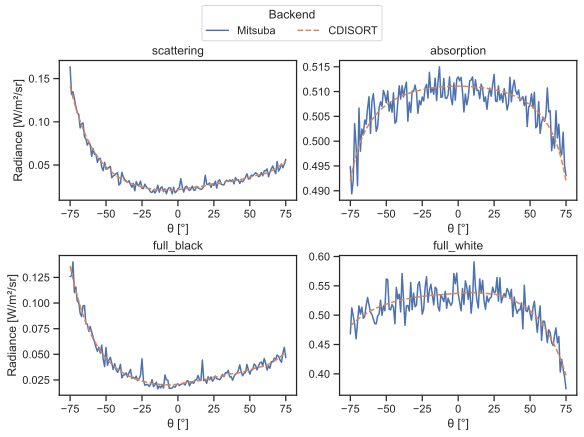

In [5]:
ncases = len(CASES)
ncols = 2
nrows = ncases // ncols + min(ncases % ncols, 1)

fig, axs = plt.subplots(
    nrows, ncols, figsize=(4 * ncols, 3 * nrows), layout="constrained", squeeze=False
)

for i, case_id in enumerate(CASES.keys()):
    icol = i % ncols
    ax = axs.ravel()[i]
    result = results[case_id]

    ax.plot(
        result["mitsuba"]["vza"], result["mitsuba"], label="Mitsuba" if i == 0 else None
    )
    ax.plot(
        result["disort"]["vza"],
        result["disort"],
        label="CDISORT" if i == 0 else None,
        ls="--",
    )

    ax.set_title(case_id)
    ax.set_xlabel("θ [°]")
    if icol == 0:
        ax.set_ylabel("Radiance [W/m²/sr]")

else:
    while (i := i + 1) < axs.size:
        ax = axs.ravel()[i]
        ax.set_axis_off()

fig.legend(title="Backend", ncol=2, loc="outside upper center")

plt.show()